In [69]:
# ▶ pd.set option
#  gender, car yes or no, reality? child number, incom total, incomr type, deucation type, family_type, house type DAYS birth should be positive, employed aso needs to be. Can be years, and months. FLAG mobile? work phone and phone
import json
import numpy as np
import pandas as pd 
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)  

# ▶ Data read
df = pd.read_csv("data/data.csv")
df.head()

,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,F,N,N,0,202500.0,Commercial associate,Higher education,Married,Municipal apartment,-13899,-4709,1,0,0,0,NaN,2.0,-6.0,1.0
1,1,F,N,Y,1,247500.0,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,-11380,-1540,1,0,0,1,Laborers,3.0,-5.0,1.0
2,2,M,Y,Y,0,450000.0,Working,Higher education,Married,House / apartment,-19087,-4434,1,0,1,0,Managers,2.0,-22.0,2.0
3,3,F,N,Y,0,202500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15088,-2092,1,0,1,0,Sales staff,2.0,-37.0,0.0
4,4,F,Y,Y,0,157500.0,State servant,Higher education,Married,House / apartment,-15037,-2105,1,0,0,0,Managers,2.0,-26.0,2.0


In [70]:
# Working, commercial associate, pernsioner, ... Very rare studentd.
df['income_type'].value_counts()

income_type
Working                 13645
Commercial associate     6202
Pensioner                4449
State servant            2154
Student                     7
Name: count, dtype: int64

In [71]:
# make the income type into code? Why?
dic_cd =  {'Working': 'code1',
           'Commercial associate':'code2',
           'Pensioner': 'code3',  
           'State servant': 'code4',
           'Student': 'code5'}

In [72]:
dic_cd

{'Working': 'code1',
 'Commercial associate': 'code2',
 'Pensioner': 'code3',
 'State servant': 'code4',
 'Student': 'code5'}

In [73]:
df['income_type'] = df['income_type'].apply(lambda x : dic_cd[x])

In [74]:
df.head(2)

,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,F,N,N,0,202500.0,code2,Higher education,Married,Municipal apartment,-13899,-4709,1,0,0,0,NaN,2.0,-6.0,1.0
1,1,F,N,Y,1,247500.0,code2,Secondary / secondary special,Civil marriage,House / apartment,-11380,-1540,1,0,0,1,Laborers,3.0,-5.0,1.0


In [75]:
df.shape

(26457, 20)

In [76]:
print(df.iloc[1,:]) # First index and every columns value
print('--------------------------')
print(df.info())

index                                        1
gender                                       F
car                                          N
reality                                      Y
child_num                                    1
income_total                          247500.0
income_type                              code2
edu_type         Secondary / secondary special
family_type                     Civil marriage
house_type                   House / apartment
DAYS_BIRTH                              -11380
DAYS_EMPLOYED                            -1540
FLAG_MOBIL                                   1
work_phone                                   0
phone                                        0
email                                        1
occyp_type                            Laborers
family_size                                3.0
begin_month                               -5.0
credit                                     1.0
Name: 1, dtype: object
--------------------------
<class 'pa

In [77]:
print(df.isnull().sum())

index               0
gender              0
car                 0
reality             0
child_num           0
income_total        0
income_type         0
edu_type            0
family_type         0
house_type          0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
FLAG_MOBIL          0
work_phone          0
phone               0
email               0
occyp_type       8171
family_size         0
begin_month         0
credit              0
dtype: int64


In [78]:
df_null = pd.DataFrame(df.isnull().sum(), columns=['null'])
df_null['null_ratio'] = df_null['null']/len(df)
df_null.sort_values(by=['null_ratio'], ascending=False)

,null,null_ratio
occyp_type,8171,0.308841
index,0,0.000000
gender,0,0.000000
begin_month,0,0.000000
family_size,0,0.000000
email,0,0.000000
phone,0,0.000000
work_phone,0,0.000000
FLAG_MOBIL,0,0.000000
DAYS_EMPLOYED,0,0.000000


In [79]:
# ▶ null 값이 전체 Data set의 70% 초과인 col 추출 
list(df_null[df_null['null_ratio'] > 0.70].index)

[]

In [80]:
# ▶ 30% NA col 사용 결정, 'ETC'로 처리 
df['occyp_type'] = df['occyp_type'].fillna('others')
df.isnull().sum()

index            0
gender           0
car              0
reality          0
child_num        0
income_total     0
income_type      0
edu_type         0
family_type      0
house_type       0
DAYS_BIRTH       0
DAYS_EMPLOYED    0
FLAG_MOBIL       0
work_phone       0
phone            0
email            0
occyp_type       0
family_size      0
begin_month      0
credit           0
dtype: int64

In [81]:
# ▶ occyp_type null 처리 확인
df['occyp_type'].value_counts()

occyp_type
others                   8171
Laborers                 4512
Core staff               2646
Sales staff              2539
Managers                 2167
Drivers                  1575
High skill tech staff    1040
Accountants               902
Medicine staff            864
Cooking staff             457
Security staff            424
Cleaning staff            403
Private service staff     243
Low-skill Laborers        127
Waiters/barmen staff      124
Secretaries                97
Realty agents              63
HR staff                   62
IT staff                   41
Name: count, dtype: int64

In [82]:
list_of_df=[]

for i in df.columns:
    loop_df = pd.DataFrame({'val' : [i],
                            'zero_cnt': df[df[i] == 0].count()[0]})
    list_of_df.append(loop_df)

df_merge = pd.concat(list_of_df).reset_index(drop=True)
df_merge['zero_ratio'] = df_merge['zero_cnt'] / len(df)
df_merge.sort_values(by=['zero_ratio'], ascending=False)

,val,zero_cnt,zero_ratio
15,email,24042,0.908720
13,work_phone,20511,0.775258
14,phone,18672,0.705749
4,child_num,18340,0.693200
19,credit,3222,0.121783
18,begin_month,231,0.008731
0,index,1,0.000038
7,edu_type,0,0.000000
8,family_type,0,0.000000
9,house_type,0,0.000000


In [83]:
df.shape

(26457, 20)

In [84]:
df.head()

,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,F,N,N,0,202500.0,code2,Higher education,Married,Municipal apartment,-13899,-4709,1,0,0,0,others,2.0,-6.0,1.0
1,1,F,N,Y,1,247500.0,code2,Secondary / secondary special,Civil marriage,House / apartment,-11380,-1540,1,0,0,1,Laborers,3.0,-5.0,1.0
2,2,M,Y,Y,0,450000.0,code1,Higher education,Married,House / apartment,-19087,-4434,1,0,1,0,Managers,2.0,-22.0,2.0
3,3,F,N,Y,0,202500.0,code2,Secondary / secondary special,Married,House / apartment,-15088,-2092,1,0,1,0,Sales staff,2.0,-37.0,0.0
4,4,F,Y,Y,0,157500.0,code4,Higher education,Married,House / apartment,-15037,-2105,1,0,0,0,Managers,2.0,-26.0,2.0


In [85]:
# ▶ meta 정보 활용 변환 
dic_cd_meta = {'code1' : 'Working',
               'code2' : 'Commercial associate',
               'code3' : 'Pensioner',  
               'code4' : 'State servant',
               'code5' : 'Student'}

df['income_type'] = df['income_type'].apply(lambda x : dic_cd_meta[x])
df['income_type'].head()

0    Commercial associate
1    Commercial associate
2                 Working
3    Commercial associate
4           State servant
Name: income_type, dtype: object

In [86]:
# ▶ Target ratio (multi-classifiaction 문제)
print(df['credit'].value_counts())
print('')
print(df['credit'].value_counts(normalize=True))

credit
2.0    16968
1.0     6267
0.0     3222
Name: count, dtype: int64

credit
2.0    0.641343
1.0    0.236875
0.0    0.121783
Name: proportion, dtype: float64


In [87]:
import numpy as np
import pandas as pd
# ▶ numeric, categorical value 나누기
numerical_list=[]
categorical_list=[]

for i in df.columns :
  if df[i].dtypes == 'O' :
    categorical_list.append(i)
  else :
    numerical_list.append(i)


print("numerical_list:", numerical_list)
print("categorical_list:", categorical_list)

numerical_list: ['index', 'child_num', 'income_total', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'work_phone', 'phone', 'email', 'family_size', 'begin_month', 'credit']
categorical_list: ['gender', 'car', 'reality', 'income_type', 'edu_type', 'family_type', 'house_type', 'occyp_type']


In [88]:
# ▶ numerical_list value unique 값 확인 (1)
for i in numerical_list :
  print(i,":",df[i].nunique())

index : 26457
child_num : 9
income_total : 249
DAYS_BIRTH : 6621
DAYS_EMPLOYED : 3470
FLAG_MOBIL : 1
work_phone : 2
phone : 2
email : 2
family_size : 10
begin_month : 61
credit : 3


In [89]:
# ▶ numerical_list value unique 값 확인 (1)
list_of_df = []

for i in numerical_list :
 loop_df = pd.DataFrame({'val' : [i],
              'nunique': df[i].nunique()})
 list_of_df.append(loop_df)
 
df_merge  = pd.concat(list_of_df).reset_index(drop=True)
df_merge.sort_values(by=['nunique'], ascending = False)

,val,nunique
0,index,26457
3,DAYS_BIRTH,6621
4,DAYS_EMPLOYED,3470
2,income_total,249
10,begin_month,61
9,family_size,10
1,child_num,9
11,credit,3
6,work_phone,2
7,phone,2


In [90]:
# ▶ categorical_list value unique 값 확인 (1)
list_of_df = []

for i in categorical_list :
 loop_df = pd.DataFrame({'val' : [i],
              'nunique': df[i].nunique()})
 list_of_df.append(loop_df)
 
df_merge  = pd.concat(list_of_df).reset_index(drop=True)
df_merge.sort_values(by=['nunique'], ascending = False)

,val,nunique
7,occyp_type,19
6,house_type,6
3,income_type,5
4,edu_type,5
5,family_type,5
0,gender,2
1,car,2
2,reality,2


In [91]:
change_list = ['credit', 'work_phone', 'phone', 'email', 'FLAG_MOBIL']

for i in change_list :
  numerical_list.remove(i)
  

for i in change_list :
  categorical_list.append(i)

print("numerical_list:", numerical_list)
print("categorical_list:", categorical_list)

numerical_list: ['index', 'child_num', 'income_total', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'family_size', 'begin_month']
categorical_list: ['gender', 'car', 'reality', 'income_type', 'edu_type', 'family_type', 'house_type', 'occyp_type', 'credit', 'work_phone', 'phone', 'email', 'FLAG_MOBIL']


### Null값 확인, 비율 확인, numerical과 categorical columns list 나눔. 

In [92]:
# ▶ Target ratio - 2.0이 64%, 1.0이 23%, 나머지가 12%인데 이 
# ▶ credit : 12퍼센트가 높은, 23퍼센트가 그 다음 높은, 나머지는 64%. 엄청 높은 비율로 나쁜 신용도
print(df['credit'].value_counts())
print('------------------------------------------------')
print(df['credit'].value_counts(normalize=True))

credit
2.0    16968
1.0     6267
0.0     3222
Name: count, dtype: int64
------------------------------------------------
credit
2.0    0.641343
1.0    0.236875
0.0    0.121783
Name: proportion, dtype: float64


In [93]:
# ▶ 0 = 높은 신용도, 가장 신용도가 낮은 2를 찾는 문제로 해결 (Multi > Binary)
df['credit'] = np.where(df['credit'] == 2, 1, 0)
print(df['credit'].value_counts())
print('')
print(df['credit'].value_counts(normalize=True))

credit
1    16968
0     9489
Name: count, dtype: int64

credit
1    0.641343
0    0.358657
Name: proportion, dtype: float64


In [94]:
categorical_list

['gender',
 'car',
 'reality',
 'income_type',
 'edu_type',
 'family_type',
 'house_type',
 'occyp_type',
 'credit',
 'work_phone',
 'phone',
 'email',
 'FLAG_MOBIL']

In [95]:
# ▶ sample col eda
eda_df = df.groupby('occyp_type')['credit'].agg(cnt =('count'), t_cnt=('sum')).reset_index() # groupby with occyp type and show credit, aggregation count and sum.
eda_df['t_ratio'] = eda_df['t_cnt'] / eda_df['cnt'] 
eda_df.sort_values(by=['t_ratio'], ascending = False)

,occyp_type,cnt,t_cnt,t_ratio
5,HR staff,62,51,0.822581
16,Security staff,424,297,0.700472
13,Realty agents,63,44,0.698413
11,Medicine staff,864,590,0.682870
1,Cleaning staff,403,270,0.669975
9,Low-skill Laborers,127,84,0.661417
10,Managers,2167,1429,0.659437
4,Drivers,1575,1030,0.653968
18,others,8171,5266,0.644474
3,Core staff,2646,1677,0.633787


In [96]:
import warnings
warnings.filterwarnings('ignore')

# ▶ numeric
# !pip install optbinning
from optbinning import OptimalBinning

iv_df = []

for i in numerical_list : # each numerical column
  variable = i # column name
  x = df[variable].values # each value from each column
  y = df.credit # target
  # max_n_prebins
  optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3) # moptimal binning.
  optb.fit(x, y)
  # print("split points : ", optb.splits)

  binning_table = optb.binning_table
  v1 = binning_table.build()

  loop_df = pd.DataFrame({'val' : variable,
                     'IV' : [v1.loc['Totals','IV']]})
  iv_df.append(loop_df)

iv_df = pd.concat(iv_df).reset_index(drop=True)
iv_df.sort_values(by=['IV'], ascending = False)


# binning_table.plot(metric="event_rate")

,val,IV
6,begin_month,1.006220
3,DAYS_BIRTH,0.011866
4,DAYS_EMPLOYED,0.007658
2,income_total,0.002783
5,family_size,0.001626
1,child_num,0.000981
0,index,0.000894


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, -8.50)",21737,0.821597,6557,15180,0.698348,-0.25825,0.052583,0.006555
1,"[-8.50, -3.50)",3003,0.113505,1230,1773,0.590410,0.215537,0.005417,0.000676
2,"[-3.50, inf)",1717,0.064898,1702,15,0.008736,5.312705,0.948220,0.059678
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,26457,1.000000,9489,16968,0.641343,,1.006220,0.066909


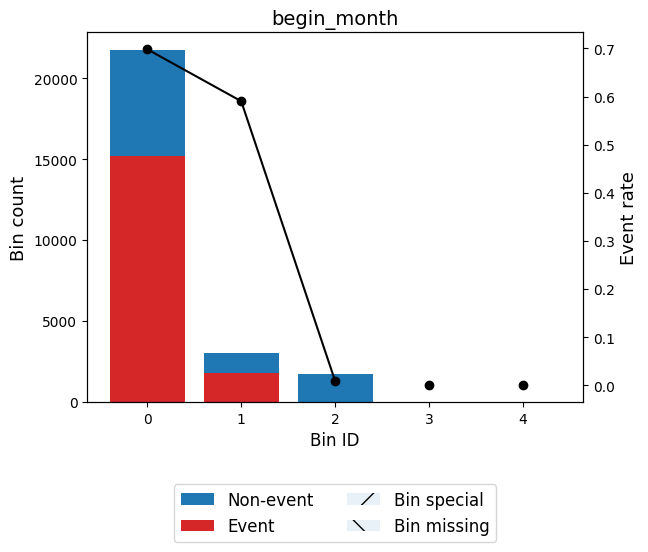

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['default'])

# ▶ numeric one col plotting 
variable = 'begin_month'
x = df[variable].values
y = df.credit
# max_n_prebins
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3)
optb.fit(x, y)
# print("split points : ", optb.splits)

binning_table = optb.binning_table
v1 = binning_table.build()

display(v1)
binning_table.plot(metric="event_rate")

count    26457.000000
mean       -26.123294
std         16.559550
min        -60.000000
25%        -39.000000
50%        -24.000000
75%        -12.000000
max          0.000000
Name: begin_month, dtype: float64


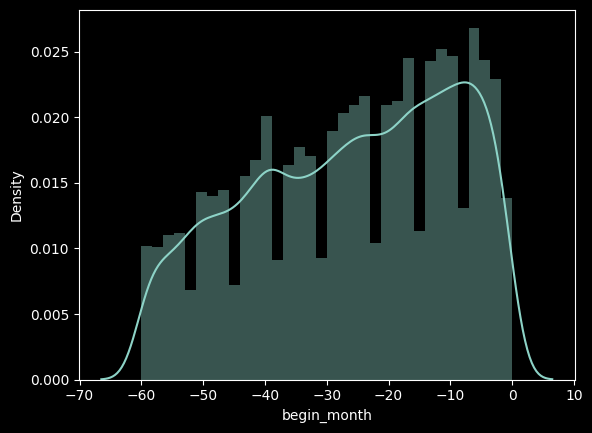

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

print(df['begin_month'].describe())
sns.distplot(df['begin_month']);

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, -13481.50)",17769,0.671618,6112,11657,0.656030,-0.064457,0.002764,0.000345
1,"[-13481.50, -9971.50)",7138,0.269796,2692,4446,0.622864,0.079476,0.001723,0.000215
2,"[-9971.50, inf)",1550,0.058586,685,865,0.558065,0.347885,0.007379,0.000918
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,26457,1.000000,9489,16968,0.641343,,0.011866,0.001478


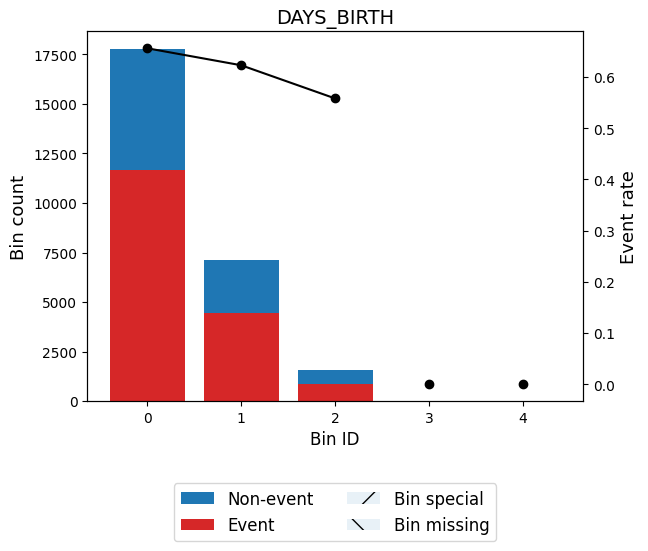

In [99]:
plt.style.use(['default'])
# ▶ numeric one col plotting 
variable = 'DAYS_BIRTH' # age
x = df[variable].values 
y = df.credit
# max_n_prebins
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3)
optb.fit(x, y)
# print("split points : ", optb.splits)

binning_table = optb.binning_table
v1 = binning_table.build()

display(v1)
binning_table.plot(metric="event_rate")

count    26457.000000
mean    -15958.053899
std       4201.589022
min     -25152.000000
25%     -19431.000000
50%     -15547.000000
75%     -12446.000000
max      -7705.000000
Name: DAYS_BIRTH, dtype: float64


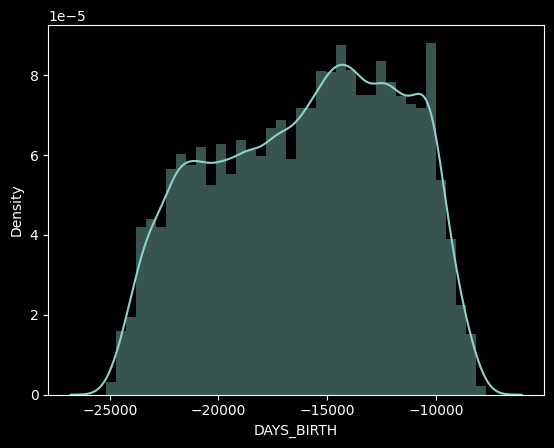

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

print(df['DAYS_BIRTH'].describe())
sns.distplot(df['DAYS_BIRTH']);

In [101]:
# ▶ bin 활용 labeling (1)
x_transform_bins = optb.transform(df['DAYS_BIRTH'], metric="bins")
df_bin = pd.DataFrame(df['credit'])
df_bin['bin'] = x_transform_bins
df_bin.head()

,credit,bin
0,0,"(-inf, -13481.50)"
1,0,"[-13481.50, -9971.50)"
2,1,"(-inf, -13481.50)"
3,0,"(-inf, -13481.50)"
4,1,"(-inf, -13481.50)"


In [102]:
# ▶ bin 활용 labeling (2)
eda_df = df_bin.groupby('bin')['credit'].agg(cnt =('count'), t_cnt=('sum')).reset_index()
eda_df['t_ratio'] = eda_df['t_cnt'] / eda_df['cnt']
eda_df

,bin,cnt,t_cnt,t_ratio
0,"(-inf, -13481.50)",17769,11657,0.656030
1,"[-13481.50, -9971.50)",7138,4446,0.622864
2,"[-9971.50, inf)",1550,865,0.558065


In [103]:
df[categorical_list].head()

,gender,car,reality,income_type,edu_type,family_type,house_type,occyp_type,credit,work_phone,phone,email,FLAG_MOBIL
0,F,N,N,Commercial associate,Higher education,Married,Municipal apartment,others,0,0,0,0,1
1,F,N,Y,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,Laborers,0,0,0,1,1
2,M,Y,Y,Working,Higher education,Married,House / apartment,Managers,1,0,1,0,1
3,F,N,Y,Commercial associate,Secondary / secondary special,Married,House / apartment,Sales staff,0,0,1,0,1
4,F,Y,Y,State servant,Higher education,Married,House / apartment,Managers,1,0,0,0,1


,gender,cnt,t_cnt,t_ratio
0,F,17697,11329,0.640165
1,M,8760,5639,0.643721


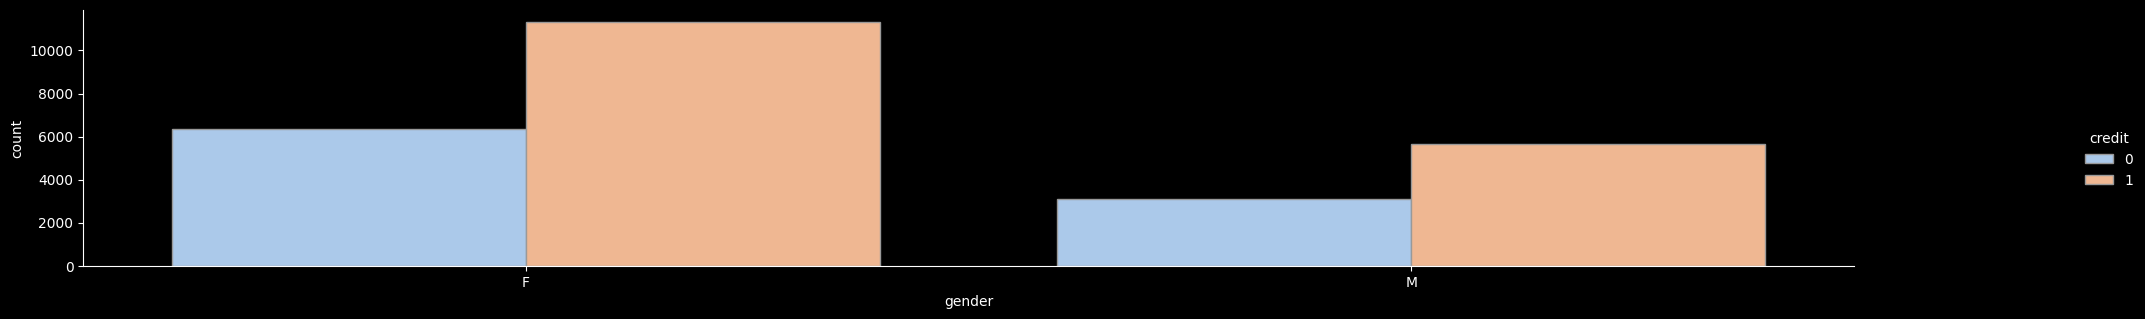

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

val = 'gender' # gender

# ▶ target 기준(hue,색상)으로 구분하여 Plot
sns.catplot(x = val, hue="credit", kind="count",palette="pastel", edgecolor=".6",data=df);
# plt.xticks(rotation=-20)
plt.gcf().set_size_inches(25, 3)

# ▶ sample col eda
eda_df = df.groupby(val)['credit'].agg(cnt =('count'), t_cnt=('sum')).reset_index() # groupby with val and show credit, aggregation count and sum.
eda_df['t_ratio'] = eda_df['t_cnt'] / eda_df['cnt'] # ratio of target, total count device cnt.
display(eda_df)

split points :  [array(['Waiters/barmen staff', 'IT staff', 'Secretaries', 'Accountants',
       'High skill tech staff'], dtype=object), array(['Sales staff'], dtype=object), array(['Private service staff', 'Laborers'], dtype=object), array(['Cooking staff', 'Core staff'], dtype=object), array(['others'], dtype=object), array(['Drivers'], dtype=object), array(['Managers', 'Low-skill Laborers', 'Cleaning staff'], dtype=object), array(['Medicine staff', 'Realty agents', 'Security staff', 'HR staff'],
      dtype=object)]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[Waiters/barmen staff, IT staff, Secretaries, ...",2204,0.083305,856,1348,0.611615,0.127089,0.001368,0.000171
1,[Sales staff],2539,0.095967,943,1596,0.628594,0.055006,0.000293,0.000037
2,"[Private service staff, Laborers]",4755,0.179726,1758,2997,0.630284,0.047761,0.000413,0.000052
3,"[Cooking staff, Core staff]",3103,0.117285,1137,1966,0.633580,0.033588,0.000133,0.000017
4,[others],8171,0.308841,2905,5266,0.644474,-0.013642,0.000057,0.000007
5,[Drivers],1575,0.059531,545,1030,0.653968,-0.055332,0.000181,0.000023
6,"[Managers, Low-skill Laborers, Cleaning staff]",2697,0.101939,914,1783,0.661105,-0.087026,0.000762,0.000095
7,"[Medicine staff, Realty agents, Security staff...",1413,0.053407,431,982,0.694975,-0.242287,0.003017,0.000376
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


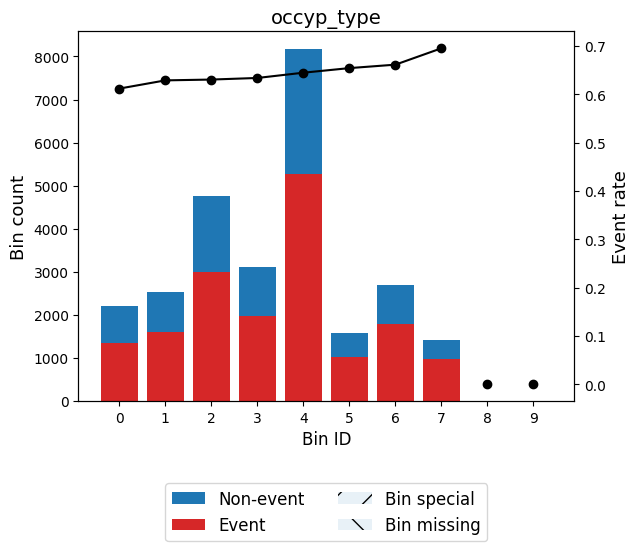

In [104]:
plt.style.use(['default'])

# ▶ Categorical one col plotting 
variable = 'occyp_type' # occupation type
x = df[variable].values # occupation values 
y = df.credit # target values
# max_n_prebins
optb = OptimalBinning(name=variable, dtype="categorical", solver="cp") # optimal binning. 
optb.fit(x, y)
print("split points : ", optb.splits)

binning_table = optb.binning_table
v1 = binning_table.build()

display(v1)
binning_table.plot(metric="event_rate")

In [105]:
optb.splits[7]

array(['Medicine staff', 'Realty agents', 'Security staff', 'HR staff'],
      dtype=object)

In [106]:
# ▶ numeric
# !pip install optbinning
from optbinning import OptimalBinning

iv_df = []

for i in categorical_list :
  variable = i # column name 
  x = df[variable].values
  y = df.credit
  # max_n_prebins
  optb = OptimalBinning(name=variable, dtype="categorical")
  optb.fit(x, y)
  # print("split points : ", optb.splits)

  binning_table = optb.binning_table
  v1 = binning_table.build()

  loop_df = pd.DataFrame({'val' : variable,
                     'IV' : [v1.loc['Totals','IV']]})
  iv_df.append(loop_df)

iv_df = pd.concat(iv_df).reset_index(drop=True)  # Information value. 
iv_df.sort_values(by=['IV'], ascending = False)


# binning_table.plot(metric="event_rate")

,val,IV
7,occyp_type,0.006224
5,family_type,0.004767
3,income_type,0.001783
6,house_type,0.001601
4,edu_type,0.001151
2,reality,0.001116
11,email,0.000967
1,car,0.000858
10,phone,0.000441
9,work_phone,0.000058


In [107]:
# ▶ numeric
# !pip install optbinning
from optbinning import OptimalBinning

iv_df = []

for i in numerical_list :
  variable = i
  x = df[variable].values
  y = df.credit
  # max_n_prebins
  optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3)
  optb.fit(x, y)
  # print("split points : ", optb.splits)

  binning_table = optb.binning_table
  v1 = binning_table.build()

  loop_df = pd.DataFrame({'val' : variable,
                     'IV' : [v1.loc['Totals','IV']]})
  iv_df.append(loop_df)

iv_df = pd.concat(iv_df).reset_index(drop=True)
iv_df.sort_values(by=['IV'], ascending = False)


# binning_table.plot(metric="event_rate")

,val,IV
6,begin_month,1.006220
3,DAYS_BIRTH,0.011866
4,DAYS_EMPLOYED,0.007658
2,income_total,0.002783
5,family_size,0.001626
1,child_num,0.000981
0,index,0.000894


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, -8.50)",21737,0.821597,6557,15180,0.698348,-0.25825,0.052583,0.006555
1,"[-8.50, -3.50)",3003,0.113505,1230,1773,0.590410,0.215537,0.005417,0.000676
2,"[-3.50, inf)",1717,0.064898,1702,15,0.008736,5.312705,0.948220,0.059678
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,26457,1.000000,9489,16968,0.641343,,1.006220,0.066909


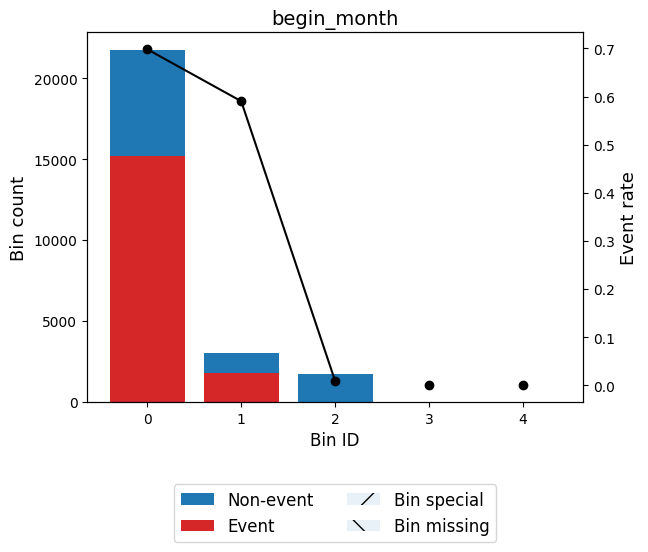

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['default'])

# ▶ numeric one col plotting 
variable = 'begin_month'
x = df[variable].values
y = df.credit
# max_n_prebins
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3)
optb.fit(x, y)
# print("split points : ", optb.splits)

binning_table = optb.binning_table
v1 = binning_table.build()

display(v1)
binning_table.plot(metric="event_rate")

count    26457.000000
mean       -26.123294
std         16.559550
min        -60.000000
25%        -39.000000
50%        -24.000000
75%        -12.000000
max          0.000000
Name: begin_month, dtype: float64


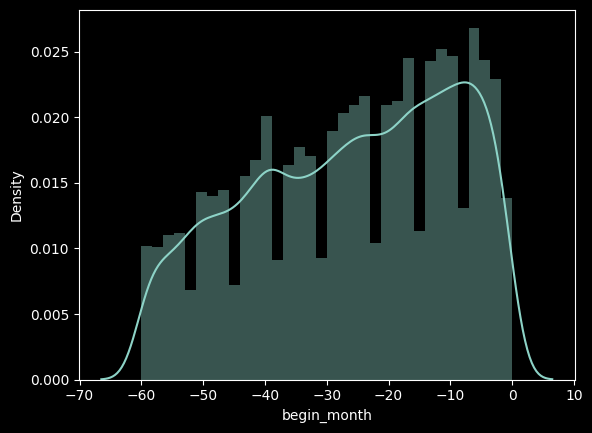

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

print(df['begin_month'].describe())
sns.distplot(df['begin_month']);

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, -13481.50)",17769,0.671618,6112,11657,0.656030,-0.064457,0.002764,0.000345
1,"[-13481.50, -9971.50)",7138,0.269796,2692,4446,0.622864,0.079476,0.001723,0.000215
2,"[-9971.50, inf)",1550,0.058586,685,865,0.558065,0.347885,0.007379,0.000918
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,26457,1.000000,9489,16968,0.641343,,0.011866,0.001478


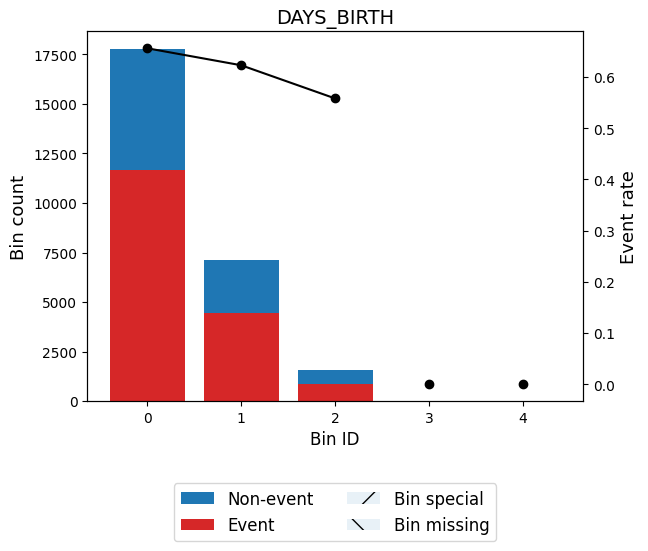

In [110]:
plt.style.use(['default'])
# ▶ numeric one col plotting 
variable = 'DAYS_BIRTH'
x = df[variable].values
y = df.credit
# max_n_prebins
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3)
optb.fit(x, y)
# print("split points : ", optb.splits)

binning_table = optb.binning_table
v1 = binning_table.build()

display(v1)
binning_table.plot(metric="event_rate")

count    26457.000000
mean    -15958.053899
std       4201.589022
min     -25152.000000
25%     -19431.000000
50%     -15547.000000
75%     -12446.000000
max      -7705.000000
Name: DAYS_BIRTH, dtype: float64


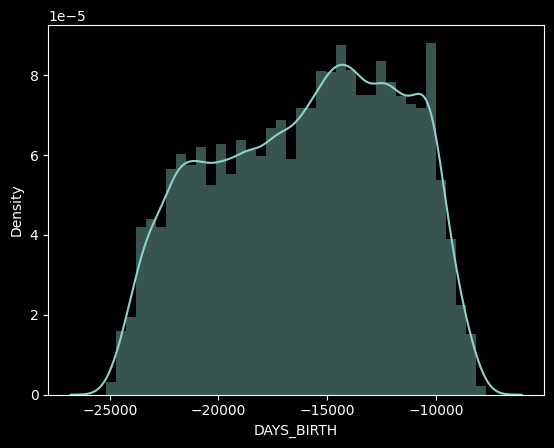

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

print(df['DAYS_BIRTH'].describe())
sns.distplot(df['DAYS_BIRTH']);

In [112]:
# ▶ bin 활용 labeling (1)
x_transform_bins = optb.transform(df['DAYS_BIRTH'], metric="bins")
df_bin = pd.DataFrame(df['credit'])
df_bin['bin'] = x_transform_bins
df_bin.head()

,credit,bin
0,0,"(-inf, -13481.50)"
1,0,"[-13481.50, -9971.50)"
2,1,"(-inf, -13481.50)"
3,0,"(-inf, -13481.50)"
4,1,"(-inf, -13481.50)"


In [113]:
# ▶ bin 활용 labeling (2)
eda_df = df_bin.groupby('bin')['credit'].agg(cnt =('count'), t_cnt=('sum')).reset_index()
eda_df['t_ratio'] = eda_df['t_cnt'] / eda_df['cnt']
eda_df

,bin,cnt,t_cnt,t_ratio
0,"(-inf, -13481.50)",17769,11657,0.656030
1,"[-13481.50, -9971.50)",7138,4446,0.622864
2,"[-9971.50, inf)",1550,865,0.558065


In [114]:
df[categorical_list].head()

,gender,car,reality,income_type,edu_type,family_type,house_type,occyp_type,credit,work_phone,phone,email,FLAG_MOBIL
0,F,N,N,Commercial associate,Higher education,Married,Municipal apartment,others,0,0,0,0,1
1,F,N,Y,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,Laborers,0,0,0,1,1
2,M,Y,Y,Working,Higher education,Married,House / apartment,Managers,1,0,1,0,1
3,F,N,Y,Commercial associate,Secondary / secondary special,Married,House / apartment,Sales staff,0,0,1,0,1
4,F,Y,Y,State servant,Higher education,Married,House / apartment,Managers,1,0,0,0,1


,gender,cnt,t_cnt,t_ratio
0,F,17697,11329,0.640165
1,M,8760,5639,0.643721


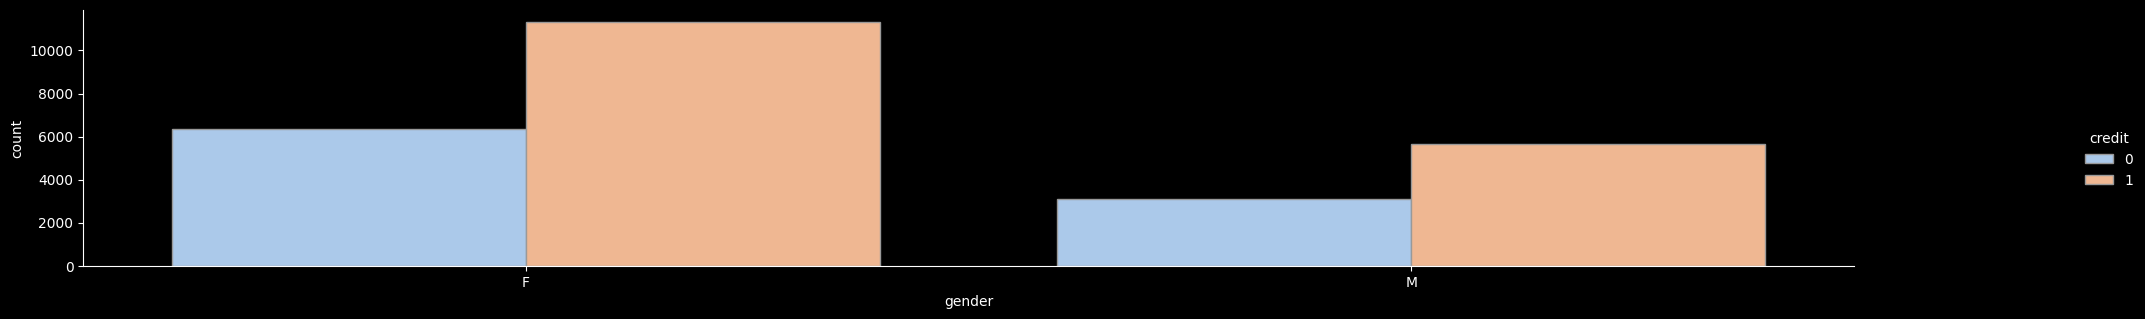

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

val = 'gender'

# ▶ target 기준(hue,색상)으로 구분하여 Plot
sns.catplot(x = val, hue="credit", kind="count",palette="pastel", edgecolor=".6",data=df);
# plt.xticks(rotation=-20)
plt.gcf().set_size_inches(25, 3)

# ▶ sample col eda
eda_df = df.groupby(val)['credit'].agg(cnt =('count'), t_cnt=('sum')).reset_index()
eda_df['t_ratio'] = eda_df['t_cnt'] / eda_df['cnt']
display(eda_df)

split points :  [array(['Waiters/barmen staff', 'IT staff', 'Secretaries', 'Accountants',
       'High skill tech staff'], dtype=object), array(['Sales staff'], dtype=object), array(['Private service staff', 'Laborers'], dtype=object), array(['Cooking staff', 'Core staff'], dtype=object), array(['others'], dtype=object), array(['Drivers'], dtype=object), array(['Managers', 'Low-skill Laborers', 'Cleaning staff'], dtype=object), array(['Medicine staff', 'Realty agents', 'Security staff', 'HR staff'],
      dtype=object)]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[Waiters/barmen staff, IT staff, Secretaries, ...",2204,0.083305,856,1348,0.611615,0.127089,0.001368,0.000171
1,[Sales staff],2539,0.095967,943,1596,0.628594,0.055006,0.000293,0.000037
2,"[Private service staff, Laborers]",4755,0.179726,1758,2997,0.630284,0.047761,0.000413,0.000052
3,"[Cooking staff, Core staff]",3103,0.117285,1137,1966,0.633580,0.033588,0.000133,0.000017
4,[others],8171,0.308841,2905,5266,0.644474,-0.013642,0.000057,0.000007
5,[Drivers],1575,0.059531,545,1030,0.653968,-0.055332,0.000181,0.000023
6,"[Managers, Low-skill Laborers, Cleaning staff]",2697,0.101939,914,1783,0.661105,-0.087026,0.000762,0.000095
7,"[Medicine staff, Realty agents, Security staff...",1413,0.053407,431,982,0.694975,-0.242287,0.003017,0.000376
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


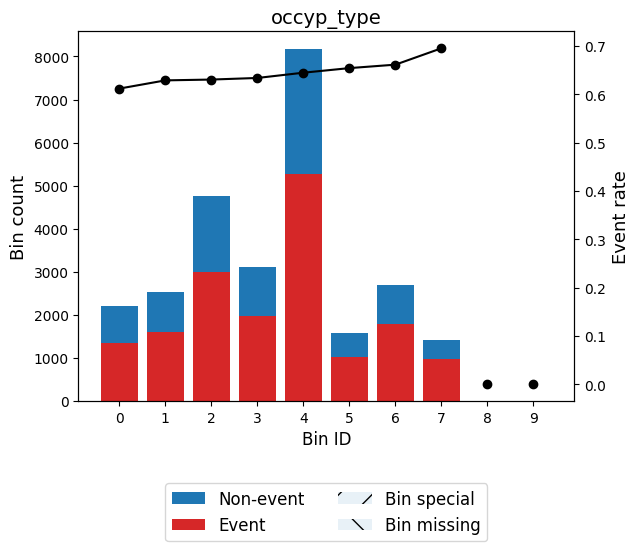

In [115]:
plt.style.use(['default'])

# ▶ Categorical one col plotting 
variable = 'occyp_type'
x = df[variable].values
y = df.credit
# max_n_prebins
optb = OptimalBinning(name=variable, dtype="categorical", solver="cp")
optb.fit(x, y)
print("split points : ", optb.splits)

binning_table = optb.binning_table
v1 = binning_table.build()

display(v1)
binning_table.plot(metric="event_rate")

In [116]:
optb.splits[7]

array(['Medicine staff', 'Realty agents', 'Security staff', 'HR staff'],
      dtype=object)

In [117]:
df.head(2)

,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,F,N,N,0,202500.0,Commercial associate,Higher education,Married,Municipal apartment,-13899,-4709,1,0,0,0,others,2.0,-6.0,0
1,1,F,N,Y,1,247500.0,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,-11380,-1540,1,0,0,1,Laborers,3.0,-5.0,0


In [118]:
from sklearn.model_selection import train_test_split

X = df.drop(['index', 'credit', 'FLAG_MOBIL'], axis=1) # Drop index, credit, FLAG_MOBIL
Y = df['credit']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=1234)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(18519, 17)
(18519,)
(7938, 17)
(7938,)


In [119]:
df[categorical_list].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26457 entries, 0 to 26456
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gender       26457 non-null  object
 1   car          26457 non-null  object
 2   reality      26457 non-null  object
 3   income_type  26457 non-null  object
 4   edu_type     26457 non-null  object
 5   family_type  26457 non-null  object
 6   house_type   26457 non-null  object
 7   occyp_type   26457 non-null  object
 8   credit       26457 non-null  int32 
 9   work_phone   26457 non-null  int64 
 10  phone        26457 non-null  int64 
 11  email        26457 non-null  int64 
 12  FLAG_MOBIL   26457 non-null  int64 
dtypes: int32(1), int64(4), object(8)
memory usage: 2.5+ MB


In [120]:
categorical_list.remove('credit')
categorical_list.remove('work_phone')
categorical_list.remove('phone')
categorical_list.remove('email')
categorical_list.remove('FLAG_MOBIL')

In [121]:
# ▶ (1) One hot encoding
from sklearn.preprocessing import OneHotEncoder

for col in categorical_list :
  encoder = OneHotEncoder()
  encoder.fit(x_train[[col]])
  onehot_train = pd.DataFrame(encoder.transform(x_train[[col]]).toarray(), columns = encoder.get_feature_names_out(), index=x_train.index)
  onehot_test = pd.DataFrame(encoder.transform(x_test[[col]]).toarray(), columns = encoder.get_feature_names_out(), index=x_test.index)
  # 기존 Col은 삭제
  x_train = pd.concat([x_train,onehot_train], axis = 1).drop(columns = [col])
  x_test = pd.concat([x_test,onehot_test], axis = 1).drop(columns = [col])

In [122]:
x_train.head()

,child_num,income_total,DAYS_BIRTH,DAYS_EMPLOYED,work_phone,phone,email,family_size,begin_month,gender_F,gender_M,car_N,car_Y,reality_N,reality_Y,income_type_Commercial associate,income_type_Pensioner,income_type_State servant,income_type_Student,income_type_Working,edu_type_Academic degree,edu_type_Higher education,edu_type_Incomplete higher,edu_type_Lower secondary,edu_type_Secondary / secondary special,family_type_Civil marriage,family_type_Married,family_type_Separated,family_type_Single / not married,family_type_Widow,house_type_Co-op apartment,house_type_House / apartment,house_type_Municipal apartment,house_type_Office apartment,house_type_Rented apartment,house_type_With parents,occyp_type_Accountants,occyp_type_Cleaning staff,occyp_type_Cooking staff,occyp_type_Core staff,occyp_type_Drivers,occyp_type_HR staff,occyp_type_High skill tech staff,occyp_type_IT staff,occyp_type_Laborers,occyp_type_Low-skill Laborers,occyp_type_Managers,occyp_type_Medicine staff,occyp_type_Private service staff,occyp_type_Realty agents,occyp_type_Sales staff,occyp_type_Secretaries,occyp_type_Security staff,occyp_type_Waiters/barmen staff,occyp_type_others
10232,2,225000.0,-10937,-1539,0,0,0,4.0,-41.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14594,0,202500.0,-8353,-1081,1,0,1,2.0,-13.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1685,1,135000.0,-13108,-1299,0,0,0,3.0,-25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12841,0,135000.0,-21374,365243,0,0,0,2.0,-1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7881,0,112500.0,-20775,365243,0,0,0,2.0,-12.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [123]:
x_test.head()

,child_num,income_total,DAYS_BIRTH,DAYS_EMPLOYED,work_phone,phone,email,family_size,begin_month,gender_F,gender_M,car_N,car_Y,reality_N,reality_Y,income_type_Commercial associate,income_type_Pensioner,income_type_State servant,income_type_Student,income_type_Working,edu_type_Academic degree,edu_type_Higher education,edu_type_Incomplete higher,edu_type_Lower secondary,edu_type_Secondary / secondary special,family_type_Civil marriage,family_type_Married,family_type_Separated,family_type_Single / not married,family_type_Widow,house_type_Co-op apartment,house_type_House / apartment,house_type_Municipal apartment,house_type_Office apartment,house_type_Rented apartment,house_type_With parents,occyp_type_Accountants,occyp_type_Cleaning staff,occyp_type_Cooking staff,occyp_type_Core staff,occyp_type_Drivers,occyp_type_HR staff,occyp_type_High skill tech staff,occyp_type_IT staff,occyp_type_Laborers,occyp_type_Low-skill Laborers,occyp_type_Managers,occyp_type_Medicine staff,occyp_type_Private service staff,occyp_type_Realty agents,occyp_type_Sales staff,occyp_type_Secretaries,occyp_type_Security staff,occyp_type_Waiters/barmen staff,occyp_type_others
23860,0,211500.0,-17249,-1661,1,1,0,2.0,-43.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
26267,0,292500.0,-13434,-3515,0,0,1,1.0,-21.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13972,0,90000.0,-19042,-3319,0,0,0,1.0,-15.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16839,1,90000.0,-9087,-1051,0,0,0,3.0,-1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26452,2,225000.0,-12079,-1984,0,0,0,4.0,-2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [124]:
# ▶ Logistic Regression 표준화(standardization) (※정규화(0~1), Normalization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train) # 
x_test_sc = scaler.transform(x_test) # 

In [125]:
# ▶ Model 학습
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(x_train_sc, y_train)

LogisticRegression()

In [126]:
from sklearn.metrics import classification_report

# ▶ 예측 및 성능 확인
y_pred_train = LR.predict(x_train_sc)
y_pred_test = LR.predict(x_test_sc)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.71      0.12      0.20      6642
           1       0.66      0.97      0.79     11877

    accuracy                           0.67     18519
   macro avg       0.68      0.55      0.50     18519
weighted avg       0.68      0.67      0.58     18519

              precision    recall  f1-score   support

           0       0.69      0.12      0.21      2847
           1       0.66      0.97      0.79      5091

    accuracy                           0.67      7938
   macro avg       0.68      0.55      0.50      7938
weighted avg       0.67      0.67      0.58      7938



In [127]:
# ▶ 과적합 문제, Train과 Test set에 성능을 최대한 줄여주는 것이 과적합을 방지
from sklearn.metrics import roc_auc_score

y_pred_train_proba = LR.predict_proba(x_train_sc)[:, 1] 
y_pred_test_proba = LR.predict_proba(x_test_sc)[:, 1] 


roc_score_train = roc_auc_score(y_train, y_pred_train_proba)
roc_score_test = roc_auc_score(y_test, y_pred_test_proba)

print("roc_score_train :", roc_score_train)
print("roc_score_test :", roc_score_test)

roc_score_train : 0.6198062028799308
roc_score_test : 0.6195804327519441


In [129]:
# ▶ 여러 Model의 성능 비교를 위한 빈 DataFrame 생성
df_comparison = pd.DataFrame(columns = ['model', 'f1_train', 'f1_test', 'AUC_train', 'AUC_test'])
df_comparison.columns = ['model', 'f1_train', 'f1_test', 'AUC_train', 'AUC_test']
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test


In [134]:
# ▶ LR model에 대한 성능 값 추가
import sklearn.metrics as metrics

lr_re = pd.DataFrame({ 'model' : ['LR'],
                      'f1_train' :  metrics.f1_score(y_train,y_pred_train),
                      'f1_test' : metrics.f1_score(y_test,y_pred_test),
                      'AUC_train' : roc_auc_score(y_train, y_pred_train_proba),
                      'AUC_test' : roc_auc_score(y_test, y_pred_test_proba),}
                    )

df_comparison = pd.concat([df_comparison, lr_re], ignore_index=True) # df_compration 과 lr_r2를 합친다. 
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test
0,LR,0.788862,0.788179,0.619806,0.61958


In [135]:
# ▶ 모델링을 학습하기 위한 Feature(X)와 Target(Y)데이터를 구분하는 단계 
from sklearn.model_selection import train_test_split

X = df.drop(['index', 'credit', 'FLAG_MOBIL'], axis=1)
Y = df['credit']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=1234)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(18519, 17)
(18519,)
(7938, 17)
(7938,)


In [136]:
# ▶ (2) label encoding

from sklearn.preprocessing import LabelEncoder

for col in categorical_list :
  encoder = LabelEncoder()
  encoder.fit(x_train[[col]])
  
  # 기존 Col 대체
  x_train[col] = encoder.transform(x_train[col]) 
  x_test[col] = encoder.transform(x_test[col]) 

In [137]:
x_train.head()

,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,work_phone,phone,email,occyp_type,family_size,begin_month
10232,1,1,0,2,225000.0,2,1,1,5,-10937,-1539,0,0,0,6,4.0,-41.0
14594,1,0,1,0,202500.0,0,4,1,1,-8353,-1081,1,0,1,3,2.0,-13.0
1685,0,1,1,1,135000.0,4,4,1,1,-13108,-1299,0,0,0,18,3.0,-25.0
12841,0,0,1,0,135000.0,1,4,1,1,-21374,365243,0,0,0,18,2.0,-1.0
7881,0,1,1,0,112500.0,1,4,1,1,-20775,365243,0,0,0,18,2.0,-12.0


In [138]:
x_test.head()

,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,work_phone,phone,email,occyp_type,family_size,begin_month
23860,0,0,0,0,211500.0,4,4,1,1,-17249,-1661,1,1,0,18,2.0,-43.0
26267,0,0,1,0,292500.0,4,4,3,1,-13434,-3515,0,0,1,18,1.0,-21.0
13972,0,0,1,0,90000.0,4,4,2,1,-19042,-3319,0,0,0,18,1.0,-15.0
16839,1,1,0,1,90000.0,4,4,1,5,-9087,-1051,0,0,0,8,3.0,-1.0
26452,0,0,0,2,225000.0,2,4,1,1,-12079,-1984,0,0,0,3,4.0,-2.0


In [139]:
# ▶ RandomForest
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
#rfc = RandomForestClassifier(max_depth=2)
rfc.fit(x_train, y_train)

# ▶ 예측
y_pred_train = rfc.predict(x_train)
y_pred_test = rfc.predict(x_test)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      6642
           1       0.98      0.99      0.99     11877

    accuracy                           0.98     18519
   macro avg       0.98      0.98      0.98     18519
weighted avg       0.98      0.98      0.98     18519

              precision    recall  f1-score   support

           0       0.66      0.51      0.58      2847
           1       0.76      0.85      0.80      5091

    accuracy                           0.73      7938
   macro avg       0.71      0.68      0.69      7938
weighted avg       0.72      0.73      0.72      7938



In [140]:
# ▶ AUC
y_pred_train_proba = rfc.predict_proba(x_train)[:, 1] 
y_pred_test_proba = rfc.predict_proba(x_test)[:, 1] 

roc_score_train = roc_auc_score(y_train, y_pred_train_proba)
roc_score_test = roc_auc_score(y_test, y_pred_test_proba)

print("roc_score_train :", roc_score_train)
print("roc_score_test :", roc_score_test)

roc_score_train : 0.9991669606947068
roc_score_test : 0.7550773326235262


In [141]:
# ▶ BayesianOptimization
import numpy as np
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score


def model_evaluate(n_estimators, maxDepth):
    clf = RandomForestClassifier(
        n_estimators= int(n_estimators),
        max_depth= int(maxDepth))
    scores = cross_val_score(clf, x_train, y_train, cv=5, scoring='roc_auc')
    return np.mean(scores)
    
    
def bayesOpt(x_train, y_train):
    clfBO = BayesianOptimization(model_evaluate, {'n_estimators':  (100, 200),
                                                  'maxDepth': (2, 4)
                                                 })
    clfBO.maximize(init_points=5, n_iter=10)
    print(clfBO.res)

bayesOpt(x_train, y_train)

|   iter    |  target   | maxDepth  | n_esti... |
-------------------------------------------------
| 1         | 0.6245    | 2.635     | 117.4     |
| 2         | 0.626     | 2.993     | 155.6     |
| 3         | 0.633     | 3.668     | 109.8     |
| 4         | 0.6335    | 3.03      | 193.8     |
| 5         | 0.6331    | 3.611     | 187.0     |
| 6         | 0.6316    | 3.43      | 190.5     |
| 7         | 0.6259    | 2.149     | 198.2     |
| 8         | 0.6236    | 2.1       | 184.8     |
| 9         | 0.6246    | 2.11      | 107.3     |
| 10        | 0.6245    | 2.871     | 146.7     |
| 11        | 0.6242    | 2.741     | 151.3     |
| 12        | 0.6244    | 2.882     | 105.8     |
| 13        | 0.6335    | 3.178     | 192.5     |
| 14        | 0.6345    | 3.94      | 111.9     |
| 15        | 0.6256    | 2.045     | 111.5     |
[{'target': 0.6245391531135529, 'params': {'maxDepth': 2.635418215915437, 'n_estimators': 117.40844876586127}}, {'target': 0.6259640506837817, 'params

In [145]:
# ▶ RandomForest
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics
from sklearn.metrics import roc_auc_score

rfc = RandomForestClassifier(n_estimators=147, max_depth = 4, random_state= 1121)
rfc.fit(x_train, y_train)

# ▶ 예측
y_pred_train = rfc.predict(x_train)
y_pred_test = rfc.predict(x_test)

y_pred_train_proba = rfc.predict_proba(x_train)[:, 1] 
y_pred_test_proba = rfc.predict_proba(x_test)[:, 1] 


rfc_re = pd.DataFrame({ 'model' : ['RFC(BO)'],
                      'f1_train' :  metrics.f1_score(y_train,y_pred_train),
                      'f1_test' : metrics.f1_score(y_test,y_pred_test),
                      'AUC_train' : roc_auc_score(y_train, y_pred_train_proba),
                      'AUC_test' : roc_auc_score(y_test, y_pred_test_proba),}
                    )
# rfc_re

df_comparison = pd.concat([df_comparison, rfc_re], ignore_index=True)
df_comparison.reset_index(drop=True, inplace = True)

In [146]:
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test
0,LR,0.788862,0.788179,0.619806,0.61958
1,RFC(BO),0.812626,0.813795,0.663180,0.64457


In [147]:
# ▶ lightGBM
import lightgbm as lgbm
from lightgbm import LGBMClassifier

LGBM = lgbm.LGBMClassifier()
LGBM.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 11877, number of negative: 6642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 763
[LightGBM] [Info] Number of data points in the train set: 18519, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.641341 -> initscore=0.581191
[LightGBM] [Info] Start training from score 0.581191


LGBMClassifier()

In [148]:
# ▶ 예측
y_pred_train = LGBM.predict(x_train)
y_pred_test = LGBM.predict(x_test)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.32      0.47      6642
           1       0.72      0.99      0.83     11877

    accuracy                           0.75     18519
   macro avg       0.83      0.65      0.65     18519
weighted avg       0.80      0.75      0.71     18519

              precision    recall  f1-score   support

           0       0.84      0.27      0.41      2847
           1       0.71      0.97      0.82      5091

    accuracy                           0.72      7938
   macro avg       0.77      0.62      0.61      7938
weighted avg       0.75      0.72      0.67      7938



In [149]:
# ▶ AUC
y_pred_train_proba = LGBM.predict_proba(x_train)[:, 1] 
y_pred_test_proba = LGBM.predict_proba(x_test)[:, 1] 

roc_score_train = roc_auc_score(y_train, y_pred_train_proba)
roc_score_test = roc_auc_score(y_test, y_pred_test_proba)

print("roc_score_train :", roc_score_train)
print("roc_score_test :", roc_score_test)

roc_score_train : 0.850746936435714
roc_score_test : 0.719803027126184
